In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

In [ ]:
train_path = "/content/drive/MyDrive/Advanced Machine Learning/train.csv"
test_path  = "/content/drive/MyDrive/Advanced Machine Learning/test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train_df.info()
train_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


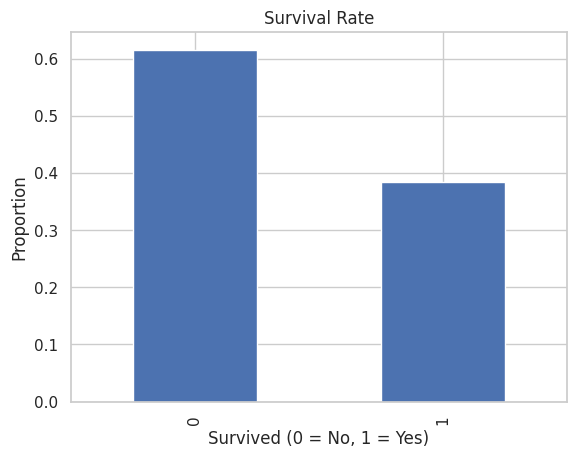

In [ ]:
train_df["Survived"].value_counts(normalize=True).plot(kind="bar")
plt.title("Survival Rate")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Proportion")
plt.show()

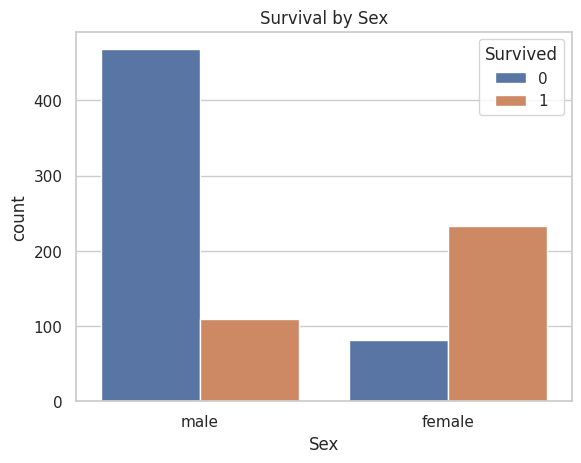

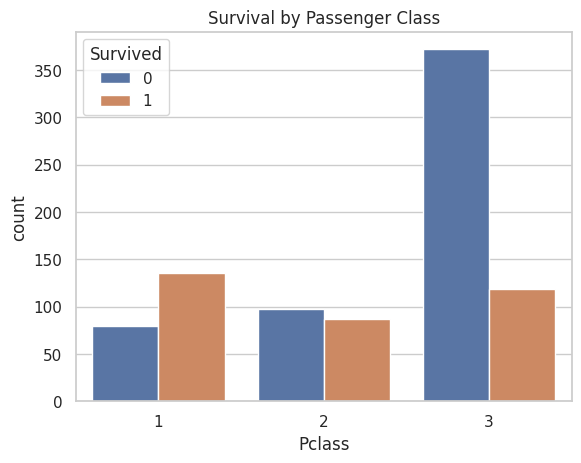

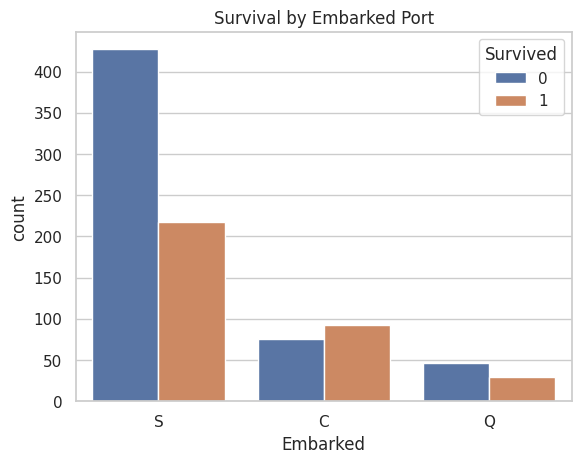

In [ ]:
# Survival by Sex
sns.countplot(data=train_df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

# Survival by Pclass
sns.countplot(data=train_df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

# Survival by Embarked
sns.countplot(data=train_df, x="Embarked", hue="Survived")
plt.title("Survival by Embarked Port")
plt.show()

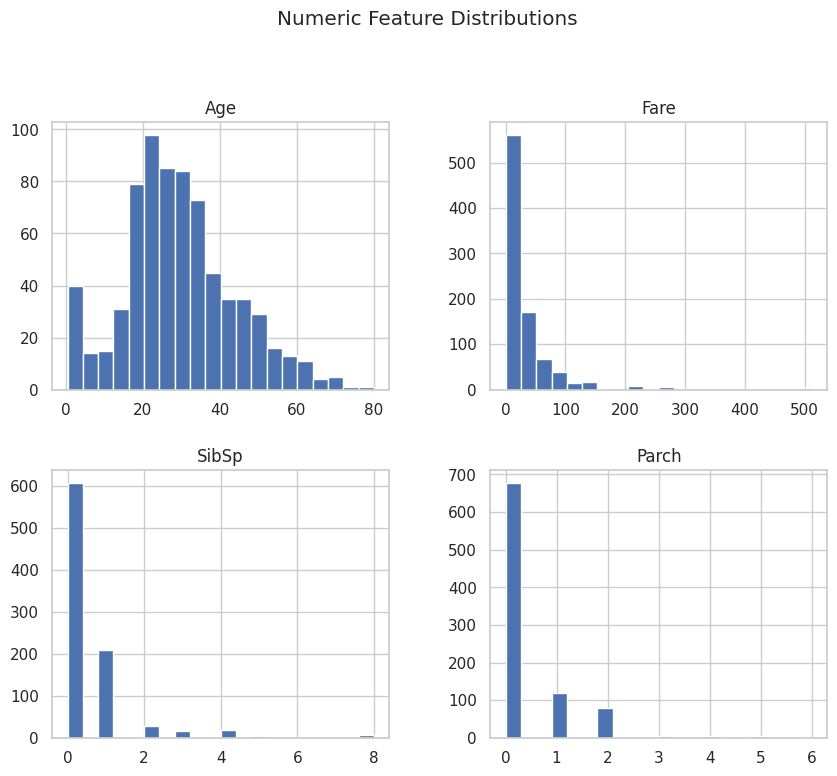

In [ ]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

train_df[numeric_cols].hist(bins=20, figsize=(10, 8))
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.show()

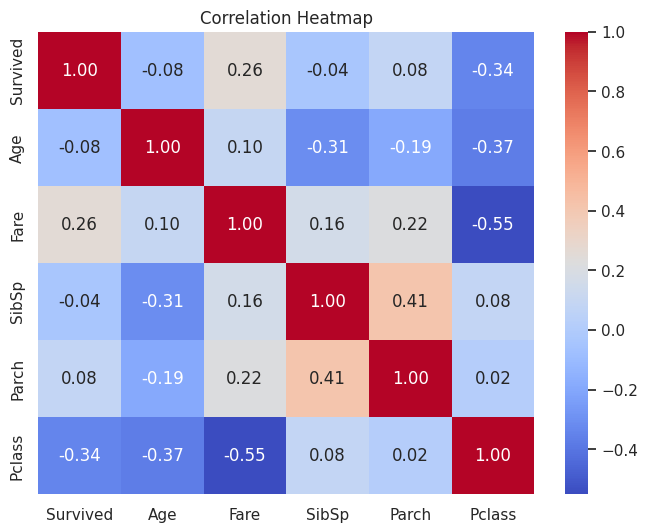

In [ ]:
# Only numeric columns, including Survived
corr = train_df[["Survived"] + numeric_cols + ["Pclass"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
def extract_title(name):
    """
    Extracts title (Mr, Mrs, Miss, Master, etc.) from the passenger's name.
    """
    if pd.isna(name):
        return "Unknown"
    title = name.split(",")[1].split(".")[0].strip()
    # Group rare titles
    rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major",
                   "Rev", "Sir", "Jonkheer", "Dona"]
    if title in rare_titles:
        return "Rare"
    if title in ["Mlle", "Ms"]:
        return "Miss"
    if title == "Mme":
        return "Mrs"
    return title


def add_features(df):
    """
    Adds engineered features:
    - FamilySize = SibSp + Parch + 1
    - IsAlone (1 if alone, 0 otherwise)
    - Title (from Name)
    - CabinKnown (1 if Cabin not null, else 0)
    """
    df = df.copy()

    # Family size
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # Is Alone
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # Title
    df["Title"] = df["Name"].apply(extract_title)

    # Cabin known
    df["CabinKnown"] = df["Cabin"].notnull().astype(int)

    return df

train_fe = add_features(train_df)
test_fe  = add_features(test_df)

train_fe[["Name", "Title", "FamilySize", "IsAlone", "Cabin", "CabinKnown"]].head()

,Name,Title,FamilySize,IsAlone,Cabin,CabinKnown
0,"Braund, Mr. Owen Harris",Mr,2,0,NaN,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,C85,1
2,"Heikkinen, Miss. Laina",Miss,1,1,NaN,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,C123,1
4,"Allen, Mr. William Henry",Mr,1,1,NaN,0


In [ ]:
# Target
y = train_fe["Survived"]


features = [
    "Pclass", "Sex", "Age", "Fare",
    "SibSp", "Parch",
    "FamilySize", "IsAlone",
    "Embarked", "Title", "CabinKnown"
]

X = train_fe[features]
X_test_final = test_fe[features]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_val.shape

((712, 11), (179, 11))

In [ ]:
numeric_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title", "IsAlone", "CabinKnown"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

cv_results = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name} CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression CV accuracy: 0.8273 ± 0.0237
Random Forest CV accuracy: 0.8160 ± 0.0102
KNN CV accuracy: 0.8020 ± 0.0169


In [ ]:

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    log_reg_pipeline,
    param_grid=param_grid_lr,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Logistic Regression params:", grid_lr.best_params_)
print("Best Logistic Regression CV accuracy:", grid_lr.best_score_)

Best Logistic Regression params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best Logistic Regression CV accuracy: 0.8272727272727274


In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid_rf,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Random Forest params:", grid_rf.best_params_)
print("Best Random Forest CV accuracy:", grid_rf.best_score_)

Best Random Forest params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best Random Forest CV accuracy: 0.8329065300896286


Validation accuracy: 0.8212290502793296

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



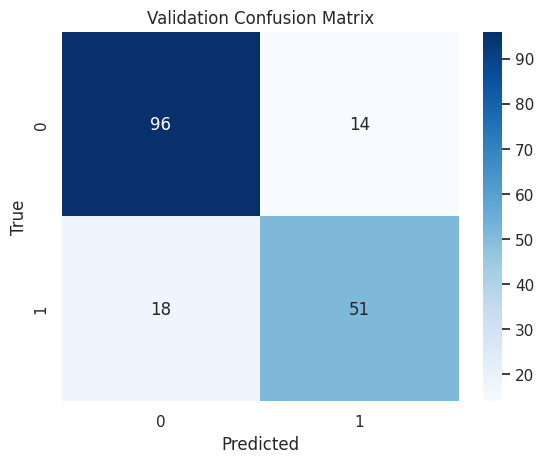

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


final_grid = grid_rf

best_model = final_grid.best_estimator_

y_val_pred = best_model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print("Validation accuracy:", val_acc)
print("\nClassification report:\n", classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# X_full and y_full from the full engineered dataset
X_full = train_fe[features]
y_full = train_fe["Survived"]

# Re-fit the grid search on all training data
final_grid_full = GridSearchCV(
    final_grid.estimator,     # same pipeline structure
    final_grid.param_grid,    # same params
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

final_grid_full.fit(X_full, y_full)

print("Best params on full data:", final_grid_full.best_params_)
print("Best CV accuracy on full data:", final_grid_full.best_score_)

Best params on full data: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV accuracy on full data: 0.8395016006528154


In [ ]:
best_model_full = final_grid_full.best_estimator_

test_predictions = best_model_full.predict(X_test_final)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [ ]:
submission.to_csv("submission.csv", index=False)
print("submission.csv file created!")

submission.csv file created!
